In [1]:
import numpy as np

In [2]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\itsar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:

import yfinance as yf

In [4]:
from datetime import datetime
end = datetime.now()
start = datetime(end.year - 20, end.month, end.day)

In [5]:
stock = 'GOOG'
google_data= yf.download(stock, start, end)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [6]:
google_data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2005-02-28,4.665436,4.712093,4.612327,4.616050,313908211
2005-03-01,4.617539,4.709116,4.516780,4.697700,373844027
2005-03-02,4.595699,4.657495,4.575349,4.614809,292512314
2005-03-03,4.641116,4.659480,4.574110,4.619277,305484756
2005-03-04,4.613568,4.647071,4.592970,4.633422,271979640
2005-03-07,4.685786,4.705393,4.641612,4.660225,347995502
2005-03-08,4.596196,4.711597,4.590488,4.692984,323050350
2005-03-09,4.500648,4.582546,4.471116,4.571627,456119263


In [7]:
google_data.shape

(5034, 5)

In [8]:
google_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,5034.000000,5034.000000,5034.000000,5034.000000,5.034000e+03
mean,49.995174,50.502653,49.475523,49.975910,1.049887e+08
std,47.962535,48.467520,47.461573,47.937793,1.350026e+08
min,4.342810,4.427437,4.282752,4.350503,1.584340e+05
25%,13.444804,13.578072,13.310169,13.475888,2.627299e+07
50%,28.503300,28.720171,28.219527,28.543124,4.907727e+07
75%,67.218855,67.773974,66.766357,67.258332,1.290780e+08
max,207.710007,208.699997,204.259995,204.500000,1.650833e+09


In [8]:
google_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5034 entries, 2005-02-28 to 2025-02-28
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   5034 non-null   float64
 1   (High, GOOG)    5034 non-null   float64
 2   (Low, GOOG)     5034 non-null   float64
 3   (Open, GOOG)    5034 non-null   float64
 4   (Volume, GOOG)  5034 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 236.0 KB


In [9]:
import matplotlib.pyplot as plt

In [10]:
def plot_graph(figsize, value,col_name):
  plt.figure()
  value.plot(figsize=figsize)
  plt.xlabel('Year')
  plt.ylabel(col_name)
  plt.show(f"{col_name} of google stock")

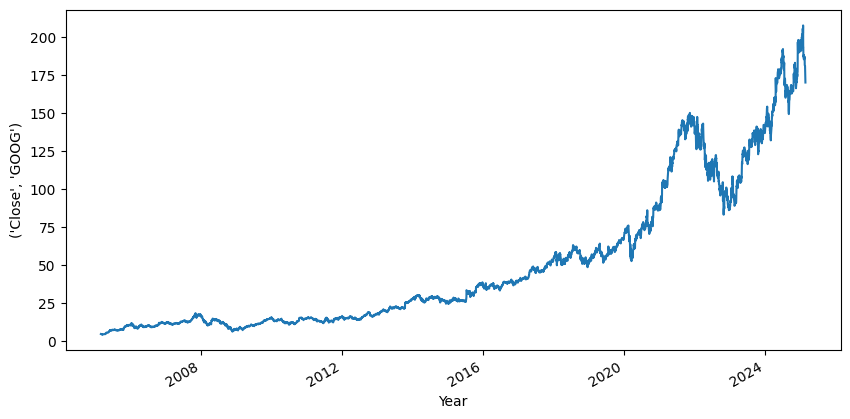

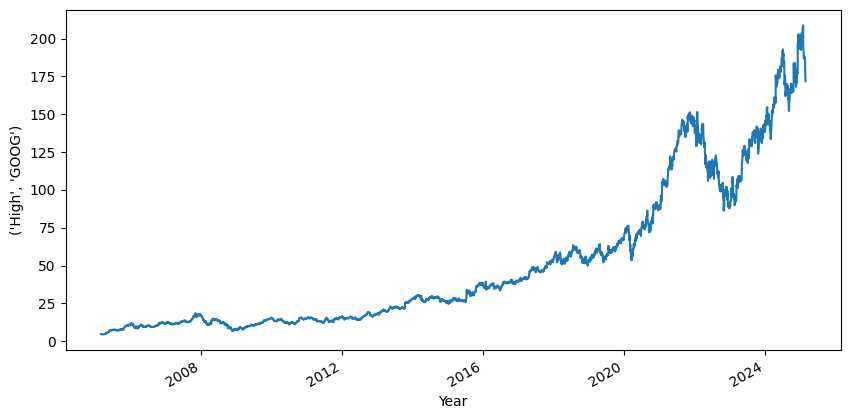

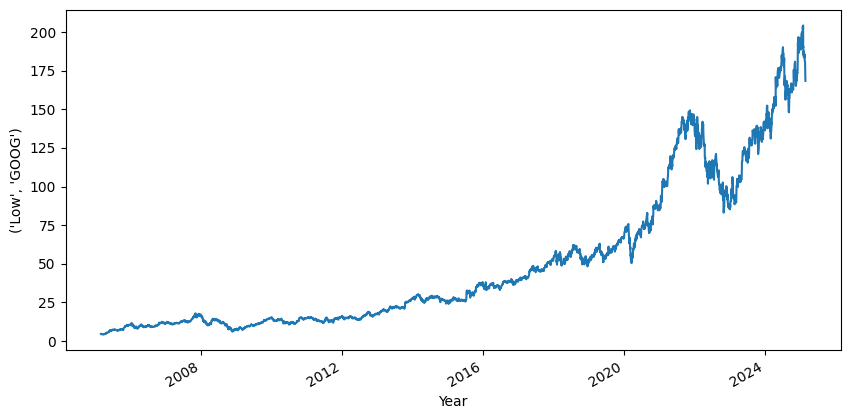

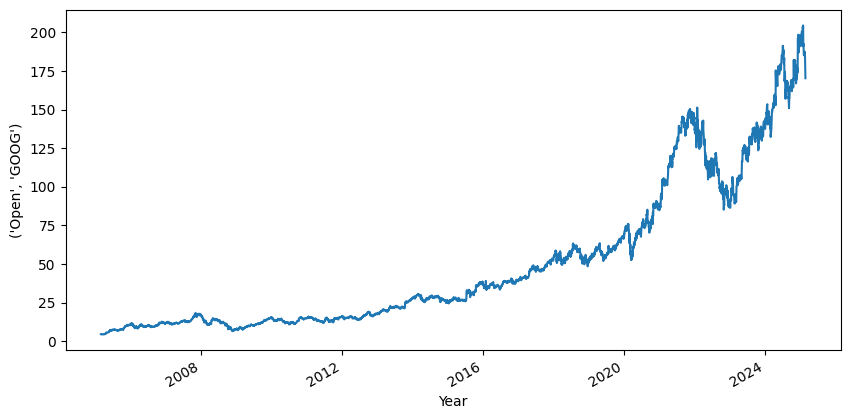

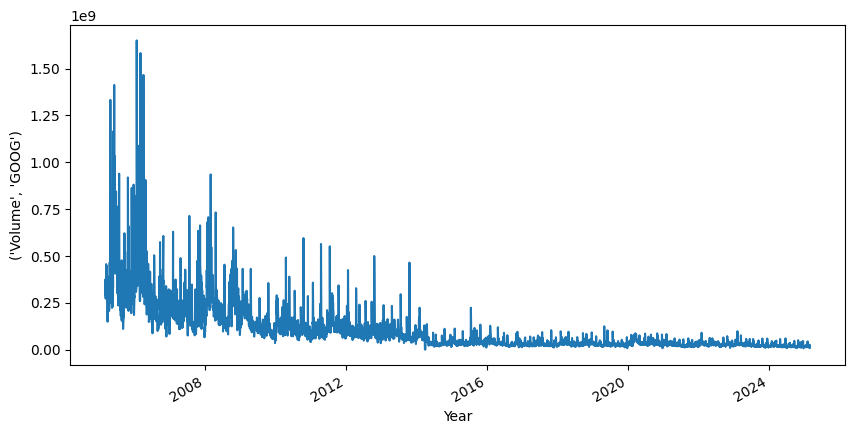

In [11]:
for column in google_data.columns:
  plot_graph((10,5), google_data[column], column)

In [12]:
temp_data  = [10,20,30,40,50,60,70,80,90,100]
print(sum(temp_data))
print(np.mean(temp_data))
print(np.median(temp_data))
print(sum(temp_data[1:6])/5)

550
55.0
55.0
40.0


In [13]:
import pandas as pd


Moving Average


In [14]:
data = pd.DataFrame( [10,20,30,40,50,60,70,80,90,100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [15]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [16]:
for i in range(2004,2025):
  print(i,list(google_data.index.year).count(i))

2004 0
2005 214
2006 251
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252


In [17]:
google_data['MA_for_250_days'] = google_data['Close'].rolling(250).mean()

In [18]:
google_data['MA_for_250_days'][0:250].tail()

Date
2006-02-16         NaN
2006-02-17         NaN
2006-02-21         NaN
2006-02-22         NaN
2006-02-23    7.686959
Name: MA_for_250_days, dtype: float64

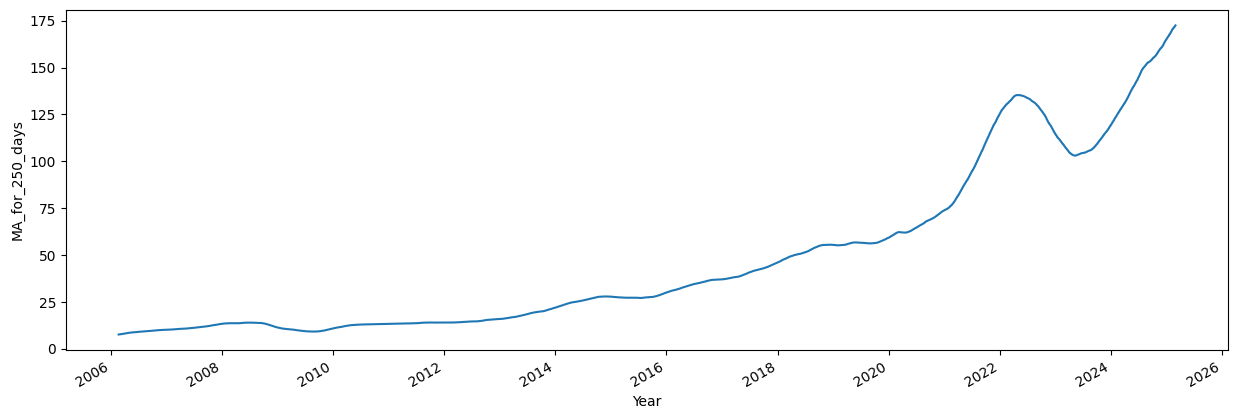

In [19]:
plot_graph((15,5), google_data['MA_for_250_days'], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

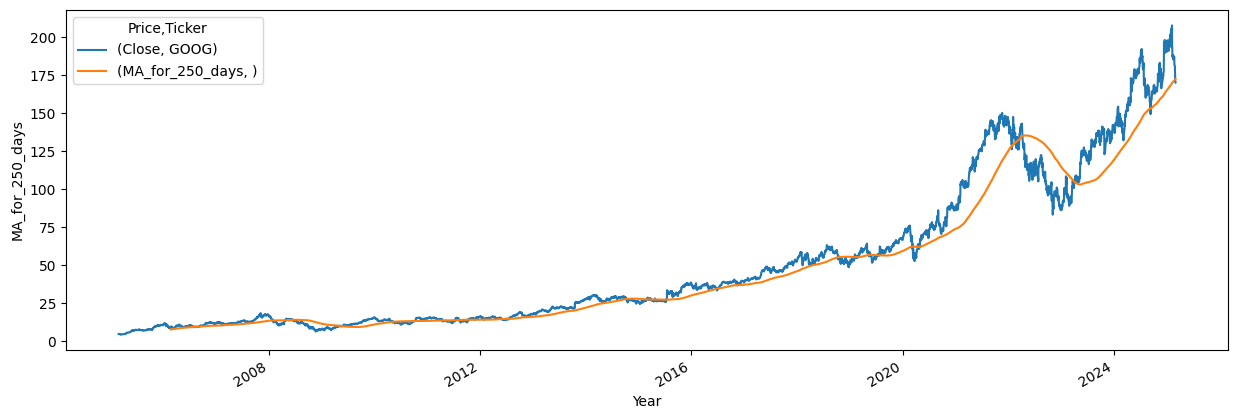

In [20]:
plot_graph((15,5), google_data[['Close','MA_for_250_days']],'MA_for_250_days' )

<Figure size 640x480 with 0 Axes>

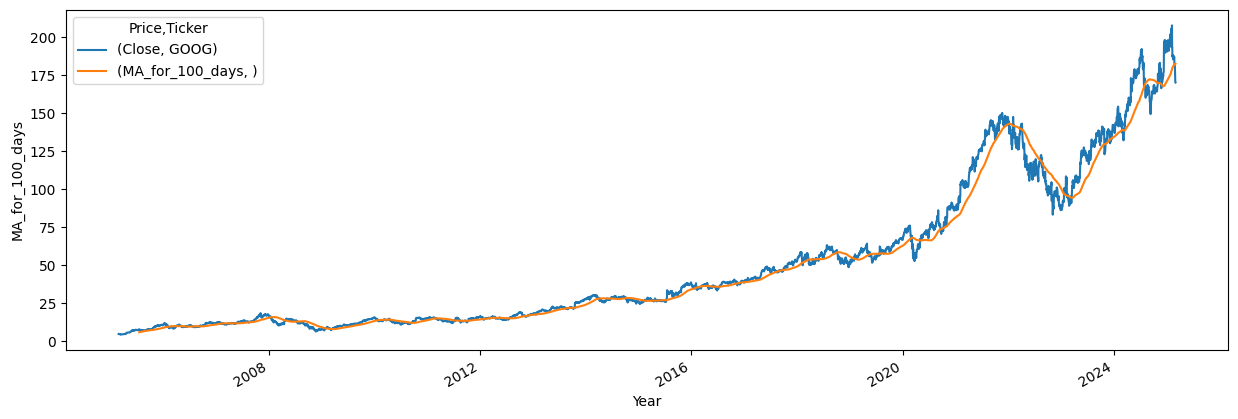

In [21]:
google_data['MA_for_100_days']  = google_data['Close'].rolling(100).mean()
plot_graph((15,5), google_data[['Close','MA_for_100_days']],'MA_for_100_days' )

<Figure size 640x480 with 0 Axes>

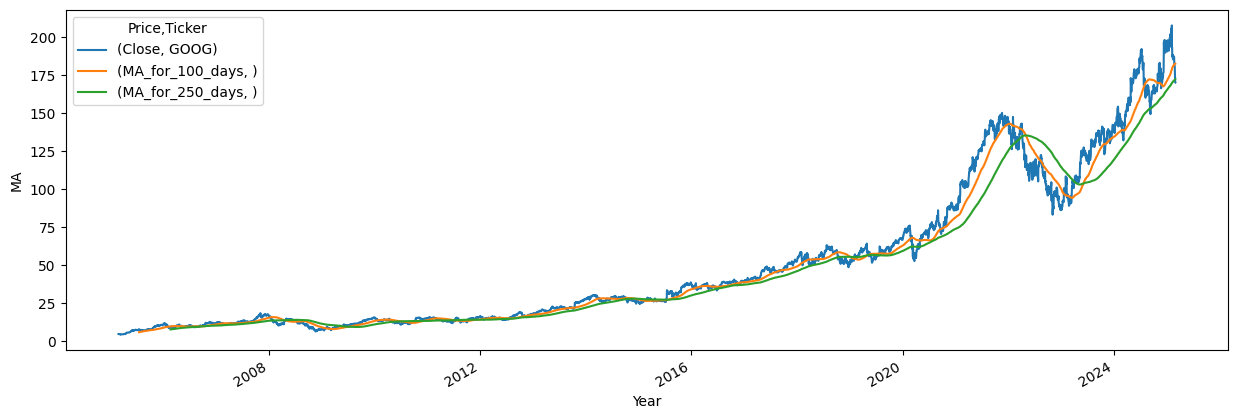

In [22]:
plot_graph((15,5), google_data[['Close','MA_for_100_days','MA_for_250_days']],'MA' )

In [23]:
google_data['percentage_change'] = google_data['Close'].pct_change()
google_data[['Close','percentage_change']].head()

Price,Close,percentage_change
Ticker,GOOG,
Date,,
2005-02-28,4.665436,NaN
2005-03-01,4.617539,-0.010266
2005-03-02,4.595699,-0.004730
2005-03-03,4.641116,0.009882
2005-03-04,4.613568,-0.005936


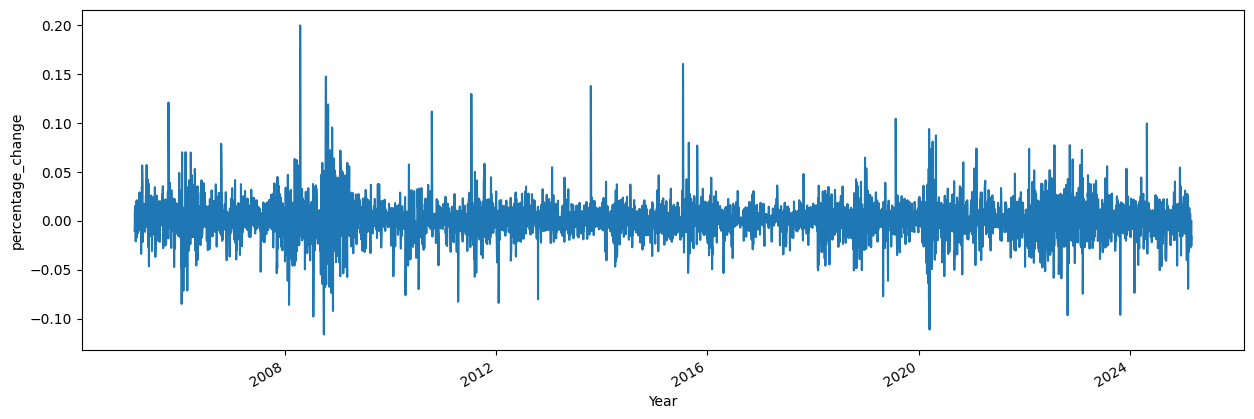

In [24]:
plot_graph((15,5), google_data['percentage_change'], 'percentage_change')

In [25]:
close_price = google_data[['Close']]
max(close_price.values),min(close_price.values)

(array([207.71000671]), array([4.34280968]))

In [26]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_price)
scaled_data

array([[0.00158642],
       [0.0013509 ],
       [0.00124351],
       ...,
       [0.83768272],
       [0.81560448],
       [0.81526024]])

In [27]:
len(scaled_data)

5034

In [28]:
x_data = []
y_data = []

for i in range (100,len(scaled_data)):
  x_data.append(scaled_data[i-100:i])
  y_data.append(scaled_data[i])

import numpy as np
x_data,y_data = np.array(x_data),np.array(y_data)


In [29]:
x_data[0],y_data[0]

(array([[1.58642394e-03],
        [1.35090249e-03],
        [1.24351241e-03],
        [1.46683434e-03],
        [1.33137574e-03],
        [1.68648914e-03],
        [1.24595325e-03],
        [7.76127240e-04],
        [6.08942363e-04],
        [3.42911534e-04],
        [0.00000000e+00],
        [4.41759830e-04],
        [7.44398621e-05],
        [5.24739127e-04],
        [6.16262549e-04],
        [7.18775627e-04],
        [4.40540581e-04],
        [4.86909572e-04],
        [5.19859785e-04],
        [7.84669020e-04],
        [5.58908590e-04],
        [6.66298666e-04],
        [6.73616507e-04],
        [6.16262549e-04],
        [1.25693822e-03],
        [1.65720606e-03],
        [1.73652526e-03],
        [2.29055217e-03],
        [2.08187764e-03],
        [2.22587802e-03],
        [2.31496060e-03],
        [2.18926772e-03],
        [2.00865703e-03],
        [1.22154716e-03],
        [1.46195031e-03],
        [2.00255844e-03],
        [2.82017767e-03],
        [3.56701948e-03],
        [4.9

In [30]:
int(len(x_data)*0.7)

3453

In [31]:
5032-100-int(len(x_data)*0.7)

1479

In [32]:
splitting_len = int(len(x_data)*0.7)
x_trian = x_data[:splitting_len]
y_trian = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]


In [33]:
print(x_trian.shape)
print(x_test.shape)
print(y_trian.shape)
print(y_test.shape)

(3453, 100, 1)
(1481, 100, 1)
(3453, 1)
(1481, 1)


In [34]:
pip install keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\itsar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.18.0-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached tensorflow_intel-2.18.0-cp312-cp312-win_amd64.whl.metadata (4.9 kB)
Using cached tensorflow-2.18.0-cp312-cp312-win_amd64.whl (7.5 kB)
Using cached tensorflow_intel-2.18.0-cp312-cp312-win_amd64.whl (390.3 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\itsar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
from keras.models import Sequential
from keras.layers import Dense,LSTM

In [37]:
model = Sequential()
model.add(LSTM(128,return_sequences=True,input_shape=(x_trian.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

C:\Users\itsar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [39]:
model.fit(x_trian,y_trian , batch_size=1,epochs=2)

Epoch 1/2
3453/3453 ━━━━━━━━━━━━━━━━━━━━ 122s 32ms/step - loss: 4.3858e-04
Epoch 2/2
3453/3453 ━━━━━━━━━━━━━━━━━━━━ 109s 31ms/step - loss: 5.2838e-05


In [40]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [41]:
predictions = model.predict(x_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step


In [42]:
predictions

array([[0.24703442],
       [0.2467809 ],
       [0.24724784],
       ...,
       [0.8259587 ],
       [0.8132791 ],
       [0.7970084 ]], dtype=float32)

In [43]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 54.581505],
       [ 54.52995 ],
       [ 54.624912],
       ...,
       [172.31572 ],
       [169.73709 ],
       [166.42816 ]], dtype=float32)

In [44]:
y_test

array([[0.27315118],
       [0.27375383],
       [0.27699982],
       ...,
       [0.83768272],
       [0.81560448],
       [0.81526024]])

In [45]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 59.89279938],
       [ 60.01535797],
       [ 60.67548752],
       ...,
       [174.69999695],
       [170.21000671],
       [170.13999939]])

In [46]:
rmse = np.sqrt(np.mean((inv_predictions-inv_y_test)**2))

In [47]:
rmse

np.float64(6.404650928737065)

In [48]:
plotting_data = pd.DataFrame(
    {
        'original_test_data':inv_y_test.reshape(-1),
        'predicted':inv_predictions.reshape(-1)
    },
    index = google_data.index[splitting_len+100:]
)
plotting_data

,original_test_data,predicted
Date,,
2019-04-10,59.892799,54.581505
2019-04-11,60.015358,54.529949
2019-04-12,60.675488,54.624912
2019-04-15,60.836411,55.026234
2019-04-16,61.136826,55.376381
...,...,...
2025-02-24,181.190002,176.867920
2025-02-25,177.369995,174.969437
2025-02-26,174.699997,172.315720


<Figure size 640x480 with 0 Axes>

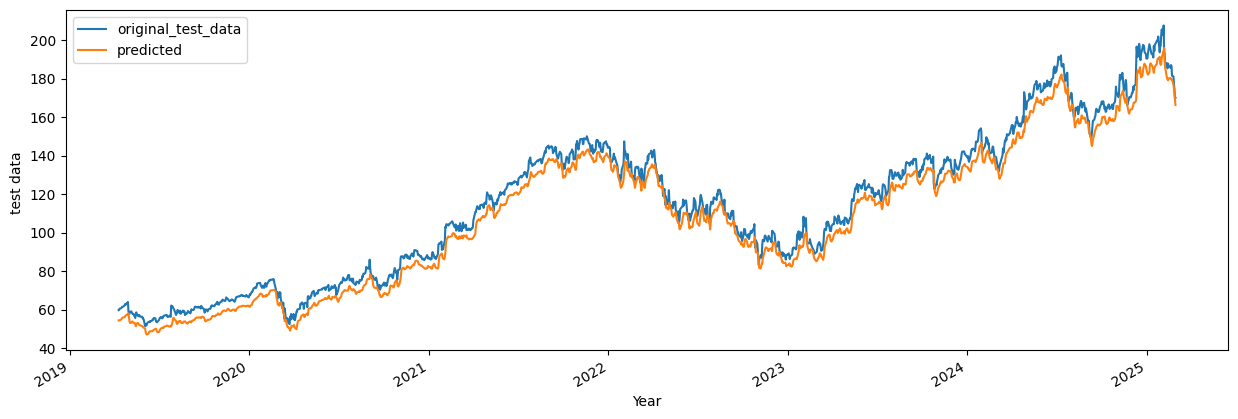

In [49]:
plot_graph((15,5), plotting_data, 'test data ')

<Figure size 640x480 with 0 Axes>

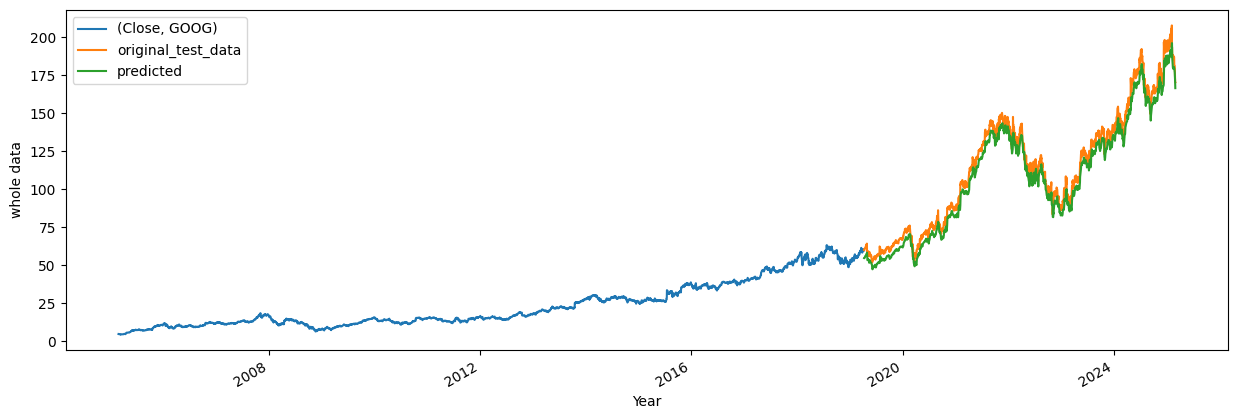

In [50]:
plot_graph((15,5),pd.concat([close_price[:splitting_len+100],plotting_data],axis=0),'whole data')

In [51]:
model.save('Latest_stock_model.keras')